# Multinomial Logistic Regression with Custom Evaluation Metrics
## Performance Enhancement and Diagnostics on MNIST

This notebook implements a **Multinomial Logistic Regression** (Softmax Regression) model built entirely from scratch, including:
- **Vanilla Mini-Batch Gradient Descent** optimizer
- **PCA + Polynomial Features** for non-linear feature expansion
- **Custom evaluation metrics** (Accuracy, Classification Report, ROC-AUC) — no `sklearn.metrics` used

> **Goal**: Achieve >90% per-class precision and recall on all 10 MNIST digit classes while maintaining full transparency into the evaluation pipeline.

## 1. Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
import os

# Create output directories
os.makedirs('outputs/figures', exist_ok=True)

## 2. Core Functions (From Scratch)

### 2.1 Softmax Activation

The softmax function converts raw logits $Z$ into class probabilities. We use a numerically stable version that shifts by the row-maximum to prevent overflow:

$$\hat{Y} = \sigma(Z) = \frac{\exp(Z - \max(Z))}{\sum \exp(Z - \max(Z))}$$

In [2]:
def softmax(Z):
    """Numerically stable softmax: shift by row-max to prevent overflow."""
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

### 2.2 Multinomial Logistic Regression Class

The model uses **Vanilla Mini-Batch Gradient Descent** with L2 regularization.

**Weight Update Rule:**

For each mini-batch at iteration $t$:

1. **Forward Pass**: $Z = XW$, then $\hat{Y} = \text{softmax}(Z)$
2. **Gradient** (with L2 regularization, excluding bias):
$$g_t = \frac{1}{m} X^T (\hat{Y} - Y) + \lambda W_{reg}$$
3. **Update**:
$$W_{t+1} = W_t - \eta \cdot g_t$$

**Loss Function** (Cross-Entropy):
$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})$$

In [3]:
class MultinomialRegression:
    """Multinomial Logistic Regression using vanilla mini-batch gradient descent."""

    def __init__(self, eta=0.005, epochs=100, batch_size=512, lam=0.01):
        self.eta = eta          # Learning rate
        self.epochs = epochs    # Number of full passes over training data
        self.batch_size = batch_size
        self.lam = lam          # L2 regularization strength
        self.W = None
        self.history_train_loss = []
        self.history_val_loss = []

    def fit(self, X_train, Y_train_onehot, X_val=None, Y_val_onehot=None):
        n_samples, n_features = X_train.shape
        n_classes = Y_train_onehot.shape[1]

        # Initialize weights to zeros
        self.W = np.zeros((n_features + 1, n_classes))

        # Prepend bias column of 1s
        X_train_b = np.c_[np.ones((n_samples, 1)), X_train]
        if X_val is not None:
            X_val_b = np.c_[np.ones((X_val.shape[0], 1)), X_val]

        self.history_train_loss = []
        self.history_val_loss = []

        for epoch in range(self.epochs):
            # Shuffle data each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train_b[indices]
            Y_shuffled = Y_train_onehot[indices]

            # Mini-batch loop
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                Y_batch = Y_shuffled[i:i + self.batch_size]
                batch_size = X_batch.shape[0]

                # Forward pass
                Z = X_batch @ self.W
                Y_hat = softmax(Z)
                error = Y_hat - Y_batch

                # Gradient + L2 regularization (exclude bias from penalty)
                grad = (1.0 / batch_size) * (X_batch.T @ error)
                W_reg = np.copy(self.W)
                W_reg[0, :] = 0  # Don't regularize the bias row
                grad += self.lam * W_reg

                # Vanilla gradient descent update
                self.W -= self.eta * grad

            # ---- End-of-epoch loss tracking ----
            Y_hat_full = softmax(X_train_b @ self.W)
            train_loss = -np.mean(np.sum(Y_train_onehot * np.log(Y_hat_full + 1e-15), axis=1))
            self.history_train_loss.append(train_loss)

            if X_val is not None and Y_val_onehot is not None:
                Y_hat_val = softmax(X_val_b @ self.W)
                val_loss = -np.mean(np.sum(Y_val_onehot * np.log(Y_hat_val + 1e-15), axis=1))
                self.history_val_loss.append(val_loss)
                if (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{self.epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

        return self

    def predict_proba(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return softmax(X_b @ self.W)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

## 3. Custom Evaluation Metrics (From Scratch)

All evaluation metrics below are implemented **without** using `sklearn.metrics`.

### 3.1 Accuracy

$$\text{Accuracy} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{I}(y_i = \hat{y}_i)$$

In [4]:
def custom_accuracy_score(y_true, y_pred):
    """Calculate accuracy as the fraction of correct predictions."""
    return np.mean(y_true == y_pred)

### 3.2 Classification Report (Precision, Recall, F1-Score)

For each class $c$, we compute:

$$\text{Precision}_c = \frac{TP_c}{TP_c + FP_c}, \quad \text{Recall}_c = \frac{TP_c}{TP_c + FN_c}$$

$$F1_c = 2 \times \frac{\text{Precision}_c \times \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

- **Macro Average**: Unweighted mean across all classes
- **Weighted Average**: Weighted by class support (number of true instances)

In [5]:
def custom_classification_report(y_true, y_pred, digits=4):
    """Generate a classification report with precision, recall, f1-score per class."""
    classes = np.unique(np.concatenate((y_true, y_pred)))
    classes = np.sort(classes)
    
    report = f"{'':<12} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}\n\n"
    
    total_support = len(y_true)
    
    macro_p, macro_r, macro_f1 = 0.0, 0.0, 0.0
    weighted_p, weighted_r, weighted_f1 = 0.0, 0.0, 0.0
    
    for c in classes:
        # Per-class confusion counts
        TP = np.sum((y_pred == c) & (y_true == c))
        FP = np.sum((y_pred == c) & (y_true != c))
        FN = np.sum((y_pred != c) & (y_true == c))
        
        support = TP + FN
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        # Accumulate for macro/weighted averages
        macro_p += precision
        macro_r += recall
        macro_f1 += f1
        
        weighted_p += precision * support
        weighted_r += recall * support
        weighted_f1 += f1 * support
        
        report += f"{c:<12} {precision:>10.{digits}f} {recall:>10.{digits}f} {f1:>10.{digits}f} {support:>10}\n"
    
    n_classes = len(classes)
    macro_p /= n_classes
    macro_r /= n_classes
    macro_f1 /= n_classes
    
    weighted_p /= total_support
    weighted_r /= total_support
    weighted_f1 /= total_support
    
    accuracy = custom_accuracy_score(y_true, y_pred)
    
    report += f"\n{'accuracy':<12} {'':>10} {'':>10} {accuracy:>10.{digits}f} {total_support:>10}\n"
    report += f"{'macro avg':<12} {macro_p:>10.{digits}f} {macro_r:>10.{digits}f} {macro_f1:>10.{digits}f} {total_support:>10}\n"
    report += f"{'weighted avg':<12} {weighted_p:>10.{digits}f} {weighted_r:>10.{digits}f} {weighted_f1:>10.{digits}f} {total_support:>10}\n"
    
    return report

### 3.3 ROC-AUC (One-vs-Rest)

The ROC-AUC is calculated using a **One-vs-Rest** approach. For each class $c$:

1. Sort predicted probabilities in descending order
2. Incrementally compute True Positive Rate ($TPR$) and False Positive Rate ($FPR$) at each distinct threshold
3. Estimate Area Under the Curve using the **Trapezoidal Rule**:

$$AUC_c = \sum_{i=1}^{K-1} \frac{(FPR_{i+1} - FPR_i) \times (TPR_{i+1} + TPR_i)}{2}$$

The final multi-class ROC-AUC is the unweighted mean of all per-class $AUC_c$ scores.

In [6]:
def roc_auc_binary(y_true_binary, y_score):
    """Compute AUC for a single binary class using the trapezoidal rule."""
    desc_score_indices = np.argsort(y_score, kind="mergesort")[::-1]
    y_score = y_score[desc_score_indices]
    y_true_binary = y_true_binary[desc_score_indices]
    
    distinct_value_indices = np.where(np.diff(y_score))[0]
    threshold_idxs = np.r_[distinct_value_indices, y_true_binary.size - 1]
    
    tps = np.cumsum(y_true_binary)[threshold_idxs]
    fps = (1 + threshold_idxs) - tps
    
    tps = np.r_[0, tps]
    fps = np.r_[0, fps]
    
    if fps[-1] <= 0 or tps[-1] <= 0:
        return np.nan
        
    fpr = fps / fps[-1]
    tpr = tps / tps[-1]
    
    auc = np.trapezoid(tpr, x=fpr)
    return auc

def custom_roc_auc_score(y_true_oh, y_pred_proba):
    """Compute multiclass ROC-AUC using One-vs-Rest averaging."""
    n_classes = y_true_oh.shape[1]
    auc_scores = []
    
    for c in range(n_classes):
        auc = roc_auc_binary(y_true_oh[:, c], y_pred_proba[:, c])
        auc_scores.append(auc)
        
    return np.mean(auc_scores)

## 4. Data Preparation

**Pipeline:**
1. Fetch the MNIST dataset (70,000 images of handwritten digits, 784 pixels each)
2. Split into 60,000 training and 10,000 test samples
3. Standardize features (zero mean, unit variance)
4. Apply **PCA** (784 → 50 components)
5. Apply **Degree-2 Polynomial Expansion** (50 → ~1,300 features)
6. One-hot encode the labels for 10 classes

In [7]:
print("Fetching MNIST...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
y = y.astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=10000, random_state=42
)

print(f"Training set: {X_train_full.shape}")
print(f"Test set:     {X_test.shape}")

Fetching MNIST...
Training set: (60000, 784)
Test set:     (10000, 784)


In [8]:
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

print("Applying PCA (784 -> 50 components)...")
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Applying Polynomial Features (degree=2)...")
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_feat = poly.fit_transform(X_train_pca)
X_test_feat = poly.transform(X_test_pca)

print(f"Final feature shape: {X_train_feat.shape}")

# One-hot encode labels
Y_train_full_oh = np.eye(10)[y_train_full]
Y_test_oh = np.eye(10)[y_test]

Scaling features...
Applying PCA (784 -> 50 components)...
Applying Polynomial Features (degree=2)...
Final feature shape: (60000, 1325)


## 5. K-Fold Cross-Validation

A **3-Fold Cross-Validation** framework is used to estimate the model's generalization capabilities on the polynomial feature space. This confirms the stability of the selected hyperparameters ($\eta = 0.005$, $\lambda = 0.01$).

In [9]:
print("--- 3-Fold Cross-Validation ---")
kf = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = []
fold = 1

for train_idx, val_idx in kf.split(X_train_feat):
    print(f"Fold {fold} Training...")
    X_f_train, X_f_val = X_train_feat[train_idx], X_train_feat[val_idx]
    Y_f_train, Y_f_val = Y_train_full_oh[train_idx], Y_train_full_oh[val_idx]
    y_f_val_labels = y_train_full[val_idx]

    model = MultinomialRegression(eta=0.005, epochs=30, batch_size=512, lam=0.01)
    model.fit(X_f_train, Y_f_train)

    preds = model.predict(X_f_val)
    acc = custom_accuracy_score(y_f_val_labels, preds)
    print(f"Fold {fold} Accuracy: {acc:.4f}")
    cv_scores.append(acc)
    fold += 1

print(f"\nMean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

--- 3-Fold Cross-Validation ---
Fold 1 Training...
Fold 1 Accuracy: 0.9684
Fold 2 Training...
Fold 2 Accuracy: 0.9649
Fold 3 Training...
Fold 3 Accuracy: 0.9692

Mean CV Accuracy: 0.9675 (+/- 0.0019)


## 6. Full Model Training & Learning Curves

Train the final model for **100 epochs** with a 80/20 train/validation split. The learning curves plot the cross-entropy loss to diagnose **overfitting vs. underfitting**.

In [10]:
print("--- Training Final Model ---")
X_train_sub, X_val_sub, Y_train_oh_sub, Y_val_oh_sub = train_test_split(
    X_train_feat, Y_train_full_oh, test_size=0.2, random_state=42
)

final_model = MultinomialRegression(eta=0.005, epochs=100, batch_size=512, lam=0.01)
final_model.fit(X_train_sub, Y_train_oh_sub, X_val_sub, Y_val_oh_sub)

--- Training Final Model ---
Epoch 10/100 - Train Loss: 0.0743 - Val Loss: 0.1554
Epoch 20/100 - Train Loss: 0.0668 - Val Loss: 0.1557
Epoch 30/100 - Train Loss: 0.0461 - Val Loss: 0.1403
Epoch 40/100 - Train Loss: 0.0389 - Val Loss: 0.1387
Epoch 50/100 - Train Loss: 0.0356 - Val Loss: 0.1368
Epoch 60/100 - Train Loss: 0.0326 - Val Loss: 0.1370
Epoch 70/100 - Train Loss: 0.0310 - Val Loss: 0.1361
Epoch 80/100 - Train Loss: 0.0295 - Val Loss: 0.1348
Epoch 90/100 - Train Loss: 0.0285 - Val Loss: 0.1327
Epoch 100/100 - Train Loss: 0.0281 - Val Loss: 0.1291


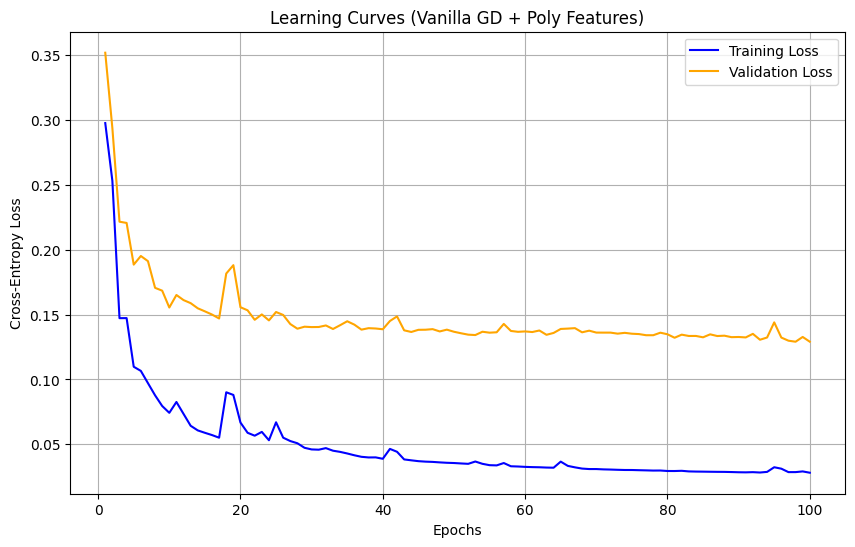

In [11]:
# Plot Learning Curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, final_model.epochs + 1), final_model.history_train_loss, label='Training Loss', color='blue')
plt.plot(range(1, final_model.epochs + 1), final_model.history_val_loss, label='Validation Loss', color='orange')
plt.title('Learning Curves (Vanilla GD + Poly Features)')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.savefig('outputs/figures/multinomial_poly_learning_curves_custom_metrics.png')
plt.show()

## 7. Bias-Variance Trade-off Analysis

The model is trained across a logarithmic scale of L2 regularization values ($\lambda \in \{0.001, 0.01, 0.1, 1.0, 10.0\}$) to analyze the bias-variance trade-off:

- **Low $\lambda$** → High variance (overfitting risk)
- **High $\lambda$** → High bias (underfitting risk)

--- Bias-Variance Tradeoff (Varying L2) ---
Epoch 10/30 - Train Loss: 0.0862 - Val Loss: 0.1680
Epoch 20/30 - Train Loss: 0.0599 - Val Loss: 0.1514
Epoch 30/30 - Train Loss: 0.0440 - Val Loss: 0.1423
Epoch 10/30 - Train Loss: 0.0857 - Val Loss: 0.1718
Epoch 20/30 - Train Loss: 0.0524 - Val Loss: 0.1518
Epoch 30/30 - Train Loss: 0.0444 - Val Loss: 0.1405
Epoch 10/30 - Train Loss: 0.0914 - Val Loss: 0.1636
Epoch 20/30 - Train Loss: 0.0717 - Val Loss: 0.1353
Epoch 30/30 - Train Loss: 0.0832 - Val Loss: 0.1476
Epoch 10/30 - Train Loss: 0.2121 - Val Loss: 0.2641
Epoch 20/30 - Train Loss: 0.2382 - Val Loss: 0.2765
Epoch 30/30 - Train Loss: 0.2263 - Val Loss: 0.2602
Epoch 10/30 - Train Loss: 0.5295 - Val Loss: 0.5817
Epoch 20/30 - Train Loss: 0.5024 - Val Loss: 0.5138
Epoch 30/30 - Train Loss: 0.4892 - Val Loss: 0.5272


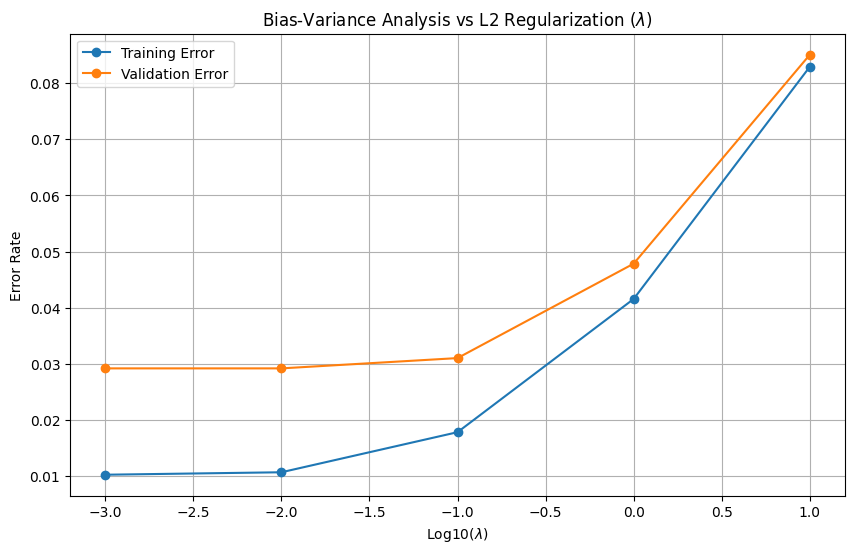

In [12]:
print("--- Bias-Variance Tradeoff (Varying L2) ---")
lams = [0.001, 0.01, 0.1, 1.0, 10.0]
train_errors = []
val_errors = []

for l in lams:
    bv_model = MultinomialRegression(eta=0.005, epochs=30, batch_size=512, lam=l)
    bv_model.fit(X_train_sub, Y_train_oh_sub, X_val_sub, Y_val_oh_sub)

    y_pred_t = bv_model.predict(X_train_sub)
    y_pred_v = bv_model.predict(X_val_sub)

    train_errors.append(1 - custom_accuracy_score(np.argmax(Y_train_oh_sub, axis=1), y_pred_t))
    val_errors.append(1 - custom_accuracy_score(np.argmax(Y_val_oh_sub, axis=1), y_pred_v))

plt.figure(figsize=(10, 6))
plt.plot(np.log10(lams), train_errors, label='Training Error', marker='o')
plt.plot(np.log10(lams), val_errors, label='Validation Error', marker='o')
plt.title(r'Bias-Variance Analysis vs L2 Regularization ($\lambda$)')
plt.xlabel(r'Log10($\lambda$)')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True)
plt.savefig('outputs/figures/multinomial_poly_bias_variance_custom_metrics.png')
plt.show()

## 8. Final Test Set Evaluation

Evaluate the trained model on the **10,000 unseen test samples** using all custom-implemented metrics.

In [13]:
print("--- Final Test Set Evaluation ---")

# 1. Training Accuracy
y_pred_train = final_model.predict(X_train_sub)
y_train_labels = np.argmax(Y_train_oh_sub, axis=1)
train_acc = custom_accuracy_score(y_train_labels, y_pred_train)
print(f"Training Accuracy: {train_acc:.4f}")

# 2. Test Accuracy
y_pred_test = final_model.predict(X_test_feat)
y_pred_proba_test = final_model.predict_proba(X_test_feat)
test_acc = custom_accuracy_score(y_test, y_pred_test)
print(f"Test Accuracy: {test_acc:.4f}")

# 3. Classification Report
print("\nClassification Report:")
print(custom_classification_report(y_test, y_pred_test, digits=4))

# 4. ROC-AUC
roc_auc = custom_roc_auc_score(Y_test_oh, y_pred_proba_test)
print(f"Multiclass ROC-AUC : {roc_auc:.4f}")

--- Final Test Set Evaluation ---
Training Accuracy: 0.9942
Test Accuracy: 0.9695

Classification Report:
              precision     recall   f1-score    support

0                0.9826     0.9776     0.9801        983
1                0.9862     0.9922     0.9892       1152
2                0.9630     0.9679     0.9654        967
3                0.9614     0.9632     0.9623       1034
4                0.9767     0.9724     0.9746        906
5                0.9670     0.9691     0.9680        937
6                0.9744     0.9886     0.9814        961
7                0.9722     0.9621     0.9671       1055
8                0.9562     0.9463     0.9512        969
9                0.9537     0.9537     0.9537       1036

accuracy                               0.9695      10000
macro avg        0.9693     0.9693     0.9693      10000
weighted avg     0.9695     0.9695     0.9695      10000

Multiclass ROC-AUC : 0.9970
